In [8]:
# Mercedes Prediction

In [9]:
!pip install pandas
!pip install matplotlib
!pip install seaborn
!pip install scikit-learn
!pip install yfinance


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [14]:
# --- imports and data loading ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import matplotlib.font_manager as fm  # ✅ FIX pour font_manager

# Set the style for better visualizations
plt.style.use('fivethirtyeight')
sns.set_palette("deep")

In [15]:
# Historical revenue data (Mercedes-Benz Group) in billions EUR
historical_revenue = {
    2019: 172.74,
    2020: 145.64,
    2021: 133.89,
    2022: 150.01,
    2023: 153.01,
    2024: 145.59,
    2025: 139.35
}

# Create DataFrame from historical data
df_historical = pd.DataFrame(list(historical_revenue.items()), columns=['Year', 'Revenue'])
df_historical['Revenue_Type'] = 'Historical'

# Optionnel: index qui commence à 1
df_historical.index = range(1, len(df_historical) + 1)

df_historical

,Year,Revenue,Revenue_Type
1,2019,172.74,Historical
2,2020,145.64,Historical
3,2021,133.89,Historical
4,2022,150.01,Historical
5,2023,153.01,Historical
6,2024,145.59,Historical
7,2025,139.35,Historical


In [41]:
def generate_projections(years_to_project=5):
    current_year = 2025
    projection_years = range(current_year + 1, current_year + years_to_project + 1)

    # --- PARTIE À MODIFIER ---
    scenarios = {
        'Pessimistic': {
            # On part de -2% pour finir à 0% (moyenne négative ou nulle)
            'growth_rate': np.linspace(-0.02, 0.00, years_to_project), 
            'volatility': 0.02,
        },
        'Neutral': {
            # Croissance stable autour de 1.5% - 2%
            'growth_rate': np.linspace(0.015, 0.02, years_to_project), 
            'volatility': 0.015,
        },
        'Optimistic': {
            # Plafond entre 3% et 4%
            'growth_rate': np.linspace(0.03, 0.04, years_to_project), 
            'volatility': 0.02,
        }
    }
    # --------------------------

    latest_revenue = historical_revenue[current_year]
    projections = {}

    for scenario, params in scenarios.items():
        revenues = [latest_revenue]

        for i, year in enumerate(projection_years):
            growth_factor = 1 + params['growth_rate'][i] + np.random.normal(0, params['volatility'])
            new_revenue = revenues[-1] * growth_factor
            revenues.append(new_revenue)

        projections[scenario] = dict(zip(projection_years, revenues[1:]))

    return projections, scenarios

projections, scenarios_info = generate_projections(years_to_project=5)

projection_data = []
for scenario, data in projections.items():
    for year, revenue in data.items():
        projection_data.append([year, revenue, scenario])

df_projections = pd.DataFrame(projection_data, columns=['Year', 'Revenue', 'Revenue_Type'])

# Ordonner par année puis par scénario dans l'ordre souhaité
scenario_order = ['Pessimistic', 'Neutral', 'Optimistic']

df_projections = df_projections.sort_values(
    by=['Year', 'Revenue_Type'],
    key=lambda col: col.map({name: i for i, name in enumerate(scenario_order)}) if col.name == 'Revenue_Type' else col
)

# Réinitialiser l'index pour qu'il commence à 1
df_projections = df_projections.reset_index(drop=True)
df_projections.index = df_projections.index + 1

df_projections

,Year,Revenue,Revenue_Type
1,2026,136.833555,Pessimistic
2,2026,138.381138,Neutral
3,2026,139.585862,Optimistic
4,2027,137.431915,Pessimistic
5,2027,141.244493,Neutral
6,2027,142.948079,Optimistic
7,2028,134.127905,Pessimistic
8,2028,144.269361,Neutral
9,2028,146.971455,Optimistic
10,2029,132.578293,Pessimistic


In [38]:
df_combined = pd.concat([df_historical.reset_index(drop=True), df_projections], ignore_index=True)

df_combined = df_combined.reset_index(drop=True)
df_combined.index = df_combined.index + 1

df_combined

,Year,Revenue,Revenue_Type
1,2019,172.740000,Historical
2,2020,145.640000,Historical
3,2021,133.890000,Historical
4,2022,150.010000,Historical
5,2023,153.010000,Historical
6,2024,145.590000,Historical
7,2025,139.350000,Historical
8,2026,138.853642,Pessimistic
9,2026,140.981081,Neutral
10,2026,142.132103,Optimistic


In [39]:
def calculate_cagr(start_value, end_value, years):
    return (end_value / start_value) ** (1 / years) - 1

cagr_data = {}
for scenario in ['Pessimistic', 'Neutral', 'Optimistic']:
    scenario_data = df_projections[df_projections['Revenue_Type'] == scenario]
    end_year = max(scenario_data['Year'])
    start_value = historical_revenue[2025]
    end_value = scenario_data[scenario_data['Year'] == end_year]['Revenue'].values[0]
    years = end_year - 2025
    cagr_data[scenario] = calculate_cagr(start_value, end_value, years)

cagr_data

{'Pessimistic': np.float64(-0.015234386524151877),
 'Neutral': np.float64(0.018300084365014957),
 'Optimistic': np.float64(0.03782869560378033)}

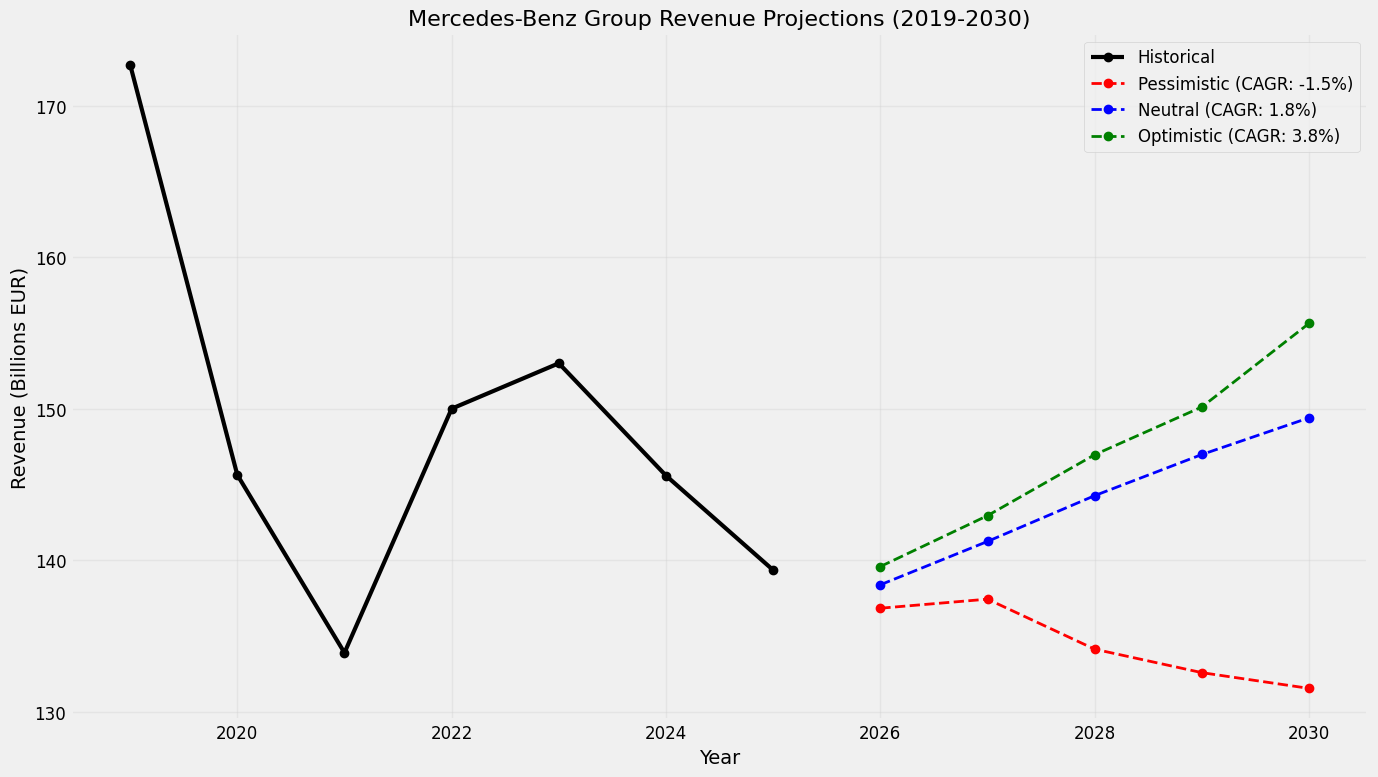

In [43]:
plt.figure(figsize=(14, 8))

# Historical data
plt.plot(df_historical['Year'], df_historical['Revenue'], 'o-', linewidth=3, color='black', label='Historical')

# Projections by scenario
colors = {'Pessimistic': 'red', 'Neutral': 'blue', 'Optimistic': 'green'}
for scenario in ['Pessimistic', 'Neutral', 'Optimistic']:
    scenario_data = df_projections[df_projections['Revenue_Type'] == scenario]
    plt.plot(scenario_data['Year'], scenario_data['Revenue'], 'o--', linewidth=2,
             color=colors[scenario], label=f"{scenario} (CAGR: {cagr_data[scenario]:.1%})")

plt.title('Mercedes-Benz Group Revenue Projections (2019-2030)', fontsize=16)
plt.xlabel('Year', fontsize=14)
plt.ylabel('Revenue (Billions EUR)', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()

In [44]:
def generate_financial_report(historical, projections, cagr_data, base_year=2025):
    report = pd.DataFrame()

    hist_years_sorted = sorted(historical.keys())
    historical_growth = []
    for i in range(1, len(hist_years_sorted)):
        year = hist_years_sorted[i]
        prev_year = hist_years_sorted[i-1]
        growth = (historical[year] / historical[prev_year]) - 1
        historical_growth.append(growth)
    avg_historical_growth = float(np.mean(historical_growth))

    years = sorted(list(set([y for scenario in projections.values() for y in scenario.keys()])))
    report['Year'] = years

    for scenario in projections.keys():
        scenario_data = projections[scenario]
        report[f'{scenario} Revenue'] = [scenario_data.get(year, None) for year in years]

    for scenario in projections.keys():
        growth_rates = []
        for i in range(len(years)):
            if i == 0:
                growth = (report[f'{scenario} Revenue'][i] / historical[base_year]) - 1
            else:
                growth = (report[f'{scenario} Revenue'][i] / report[f'{scenario} Revenue'][i-1]) - 1
            growth_rates.append(growth)
        report[f'{scenario} YoY Growth'] = growth_rates

    report_summary = pd.DataFrame({
        'Scenario': list(projections.keys()),
        f'CAGR ({base_year}-{max(years)})': [cagr_data[scenario] for scenario in projections.keys()],
        f'Avg Historical Growth ({min(hist_years_sorted)}-{max(hist_years_sorted)})': [avg_historical_growth] * len(projections)
    })

    return report, report_summary

financial_report, report_summary = generate_financial_report(historical_revenue, projections, cagr_data, base_year=2025)

financial_report = financial_report.reset_index(drop=True)
financial_report.index = financial_report.index + 1

print("Mercedes-Benz Group Revenue Projections Analysis")
print("===============================================")

print("\nHistorical Revenue (2019-2025):")
for year, revenue in historical_revenue.items():
    print(f"{year}: €{revenue:.2f} billion")

print("\nProjected Revenue (2026-2030):")
financial_report.round(2)

Mercedes-Benz Group Revenue Projections Analysis

Historical Revenue (2019-2025):
2019: €172.74 billion
2020: €145.64 billion
2021: €133.89 billion
2022: €150.01 billion
2023: €153.01 billion
2024: €145.59 billion
2025: €139.35 billion

Projected Revenue (2026-2030):


,Year,Pessimistic Revenue,Neutral Revenue,Optimistic Revenue,Pessimistic YoY Growth,Neutral YoY Growth,Optimistic YoY Growth
1,2026,136.83,138.38,139.59,-0.02,-0.01,0.00
2,2027,137.43,141.24,142.95,0.00,0.02,0.02
3,2028,134.13,144.27,146.97,-0.02,0.02,0.03
4,2029,132.58,146.99,150.12,-0.01,0.02,0.02
5,2030,131.54,149.41,155.65,-0.01,0.02,0.04


In [45]:
report_summary = report_summary.reset_index(drop=True)
report_summary.index = report_summary.index + 1

report_summary.round(4)

,Scenario,CAGR (2025-2030),Avg Historical Growth (2019-2025)
1,Pessimistic,-0.0152,-0.0314
2,Neutral,0.0183,-0.0314
3,Optimistic,0.0378,-0.0314


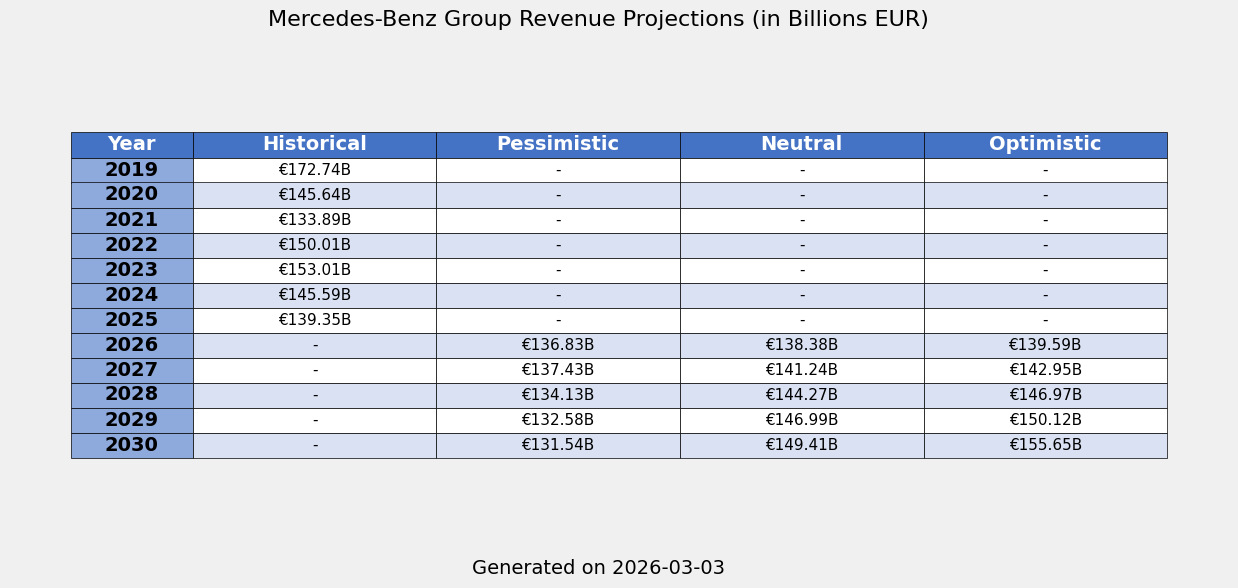

In [46]:
plt.figure(figsize=(14, 6))
ax = plt.subplot(111, frame_on=False)
ax.xaxis.set_visible(False)
ax.yaxis.set_visible(False)

table_data = []
table_data.append(['Year', 'Historical', 'Pessimistic', 'Neutral', 'Optimistic'])

for year in range(2019, 2031):
    row = [str(year)]

    if year in historical_revenue:
        row.append(f"€{historical_revenue[year]:.2f}B")
    else:
        row.append("-")

    if year > 2025:
        for scenario in ['Pessimistic', 'Neutral', 'Optimistic']:
            scenario_data = projections[scenario]
            row.append(f"€{scenario_data[year]:.2f}B" if year in scenario_data else "-")
    else:
        row.extend(["-", "-", "-"])

    table_data.append(row)

table = plt.table(
    cellText=table_data,
    cellLoc='center',
    loc='center',
    colWidths=[0.1, 0.2, 0.2, 0.2, 0.2]
)

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 1.5)

for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_text_props(fontproperties=fm.FontProperties(weight='bold'))
        cell.set_facecolor('#4472C4')
        cell.set_text_props(color='white')
    elif col == 0:
        cell.set_text_props(fontproperties=fm.FontProperties(weight='bold'))
        cell.set_facecolor('#8EA9DB')
    elif row % 2 == 0:
        cell.set_facecolor('#D9E1F2')

plt.suptitle('Mercedes-Benz Group Revenue Projections (in Billions EUR)', fontsize=16, y=0.95)
plt.figtext(0.5, 0.01, 'Generated on ' + datetime.now().strftime("%Y-%m-%d"), ha='center')
plt.show()